In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import os
import pandas as pd
import re
import plotly.express as px

PROJECT_ROOT = Path.cwd().parents[0]
SRC_PATH = PROJECT_ROOT / "src"
sys.path.append(str(SRC_PATH))

from MicroNAV.adapters.outbound.db.sqlite_db import Db_datos


from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]
DB_PATH = PROJECT_ROOT / "data" / "microvap.db"
DATA_RAW = PROJECT_ROOT / "data" / "raw"

db_data = Db_datos(DB_PATH)

/home/versekert/Documentos/Ucts/MicroNAV/data/microvap.db


In [ ]:
df = db_data.extracData("""
                SELECT 
                s.admission_id,
                count(distinct dim_otu.otu_code) as cantidad_otus
                from 
                specimen_otu as s_otu
                inner join dim_otu on s_otu.otu_id = dim_otu.otu_id 
                inner join specimen s on s_otu.specimen_id  = s.specimen_id 
                group by s.admission_id
                """)
fig = px.histogram(df, x="cantidad_otus",marginal="box", 
                   hover_data=df.columns)
fig.show()

In [17]:
df = db_data.extracData("""
                SELECT 
                dim_otu.otu_code,
                count(s_otu.otu_id) as cantidad_id
                from 
                specimen_otu as s_otu
                inner join dim_otu on s_otu.otu_id = dim_otu.otu_id 
                inner join specimen s on s_otu.specimen_id  = s.specimen_id 
                group by dim_otu.otu_code
                """)

fig = px.histogram(df, x="cantidad_id",marginal="box", 
                   hover_data=df.columns)
fig.show()

In [11]:
df = db_data.extracData("""
                SELECT 
                dim_otu.otu_code,
                s_otu.relative_abundance 
                from 
                specimen_otu as s_otu
                inner join dim_otu on s_otu.otu_id = dim_otu.otu_id 
                inner join specimen s on s_otu.specimen_id  = s.specimen_id
                """)

fig = px.box(df, x="relative_abundance", y="otu_code", points="all")
fig.show()


In [4]:
df = db_data.extracData("""
                SELECT 
                s.admission_id,
                dim_otu.otu_code,
                s_otu.relative_abundance 
                from 
                specimen_otu as s_otu
                inner join dim_otu on s_otu.otu_id = dim_otu.otu_id 
                inner join specimen s on s_otu.specimen_id  = s.specimen_id 
                """)
len(df)

44612

In [5]:
import numpy as np
import pandas as pd

from scipy.spatial.distance import pdist, squareform
import umap
import hdbscan

# -------------------------
# 0) df ya viene de tu query:
# columns: admission_id, otu_code, relative_abundance
# -------------------------

# 1) Limpieza mínima
df = df.copy()
df["admission_id"] = df["admission_id"].astype(str).str.strip()
df["otu_code"] = df["otu_code"].astype(str).str.strip().str.lower()
df["relative_abundance"] = pd.to_numeric(df["relative_abundance"], errors="coerce")
df = df.dropna(subset=["admission_id", "otu_code", "relative_abundance"])
df = df[df["relative_abundance"] > 0].copy()

# 2) Si hay duplicados por (admission_id, otu_code), colapsa (sum)
df = (
    df.groupby(["admission_id", "otu_code"], as_index=False)["relative_abundance"]
      .sum()
)

# 3) Matriz sparse: admissions x OTUs (2000 col aprox)
X = df.pivot_table(
    index="admission_id",
    columns="otu_code",
    values="relative_abundance",
    fill_value=0.0,
    aggfunc="sum",
)

# 4) Normalización composicional por admission (para que cada fila sume 1)
row_sums = X.sum(axis=1).replace(0, np.nan)
X_rel = X.div(row_sums, axis=0).fillna(0.0)

# 5) CLR transform (Centered Log-Ratio) con pseudocount
#    Nota: CLR requiere positivos -> agregamos epsilon
epsilon = 1e-10
X_pos = X_rel + epsilon

# geometric mean por fila: exp(mean(log(x)))
logX = np.log(X_pos.to_numpy())
gm = np.exp(logX.mean(axis=1, keepdims=True))
X_clr = logX - np.log(gm)

# 6) Distancia Bray-Curtis:
#    Bray-Curtis suele usarse sobre abundancias relativas (sin CLR),
#    pero también sirve usarla sobre X_rel directamente.
#    Recomendación: usa Bray-Curtis en X_rel (más estándar en microbiome).
dist = squareform(pdist(X_rel.to_numpy(), metric="braycurtis"))

# 7) UMAP usando distancia precomputada
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="precomputed",
    random_state=42,
)
emb = reducer.fit_transform(dist)

emb_df = pd.DataFrame(emb, columns=["umap1", "umap2"], index=X_rel.index).reset_index()
emb_df = emb_df.rename(columns={"index": "admission_id"})

# 8) HDBSCAN clustering (no necesitas escoger K)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,      # ajusta: 10-30 típico
    min_samples=5,            # ajusta: más alto = más outliers
    metric="euclidean",
)
labels = clusterer.fit_predict(emb)

emb_df["cluster"] = labels

print("N admissions:", emb_df.shape[0])
print("Clusters (sin outliers):", len(set(labels)) - (1 if -1 in labels else 0))
print("Outliers (-1):", int((labels == -1).sum()))

# 9) (Opcional) Guardar resultados
# emb_df.to_csv("admission_clusters_umap_hdbscan.csv", index=False)

/home/versekert/.cache/pypoetry/virtualenvs/micronav-pAUP2BJy-py3.13/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/versekert/.cache/pypoetry/virtualenvs/micronav-pAUP2BJy-py3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


N admissions: 140
Clusters (sin outliers): 3
Outliers (-1): 33


In [6]:
# X_rel: admissions x OTUs (abundancia relativa)
res = emb_df[["admission_id", "cluster"]].merge(
    X_rel.reset_index(), on="admission_id", how="left"
)

otu_cols = [c for c in X_rel.columns]

global_mean = X_rel.mean(axis=0) + 1e-12

cluster_summaries = []
for cl in sorted([c for c in emb_df["cluster"].unique() if c != -1]):
    idx = emb_df.loc[emb_df["cluster"] == cl, "admission_id"]
    Xc = X_rel.loc[idx]

    cl_mean = Xc.mean(axis=0) + 1e-12
    enrichment = (cl_mean / global_mean).sort_values(ascending=False)

    top = enrichment.head(20).reset_index()
    top.columns = ["otu_code", "enrichment_ratio"]
    top["cluster"] = cl
    top["cluster_size"] = Xc.shape[0]
    cluster_summaries.append(top)

df_top_otus = pd.concat(cluster_summaries, ignore_index=True)
print(df_top_otus.head(30))

# df_top_otus.to_csv("top_otus_by_cluster.csv", index=False)

   otu_code  enrichment_ratio  cluster  cluster_size
0    otu693          8.750000        0            16
1    otu716          8.750000        0            16
2   otu1153          8.750000        0            16
3    otu978          8.750000        0            16
4    otu898          8.750000        0            16
5    otu905          8.750000        0            16
6    otu992          8.750000        0            16
7   otu1219          8.750000        0            16
8    otu457          8.750000        0            16
9   otu1695          8.750000        0            16
10   otu851          8.750000        0            16
11  otu1188          8.750000        0            16
12  otu1327          8.750000        0            16
13  otu1351          8.750000        0            16
14  otu1426          8.750000        0            16
15   otu360          8.750000        0            16
16  otu4772          8.750000        0            16
17   otu714          8.750000        0        

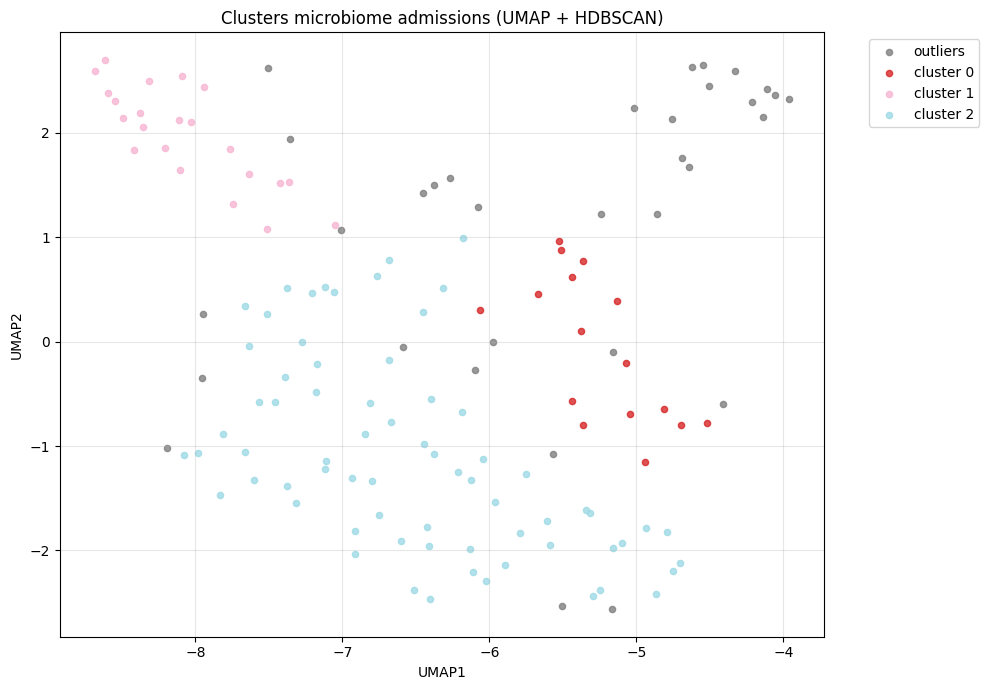

In [7]:
import matplotlib.pyplot as plt
import numpy as np

x = emb_df["umap1"].values
y = emb_df["umap2"].values
labels = emb_df["cluster"].values

unique_clusters = sorted(np.unique(labels))

# Paleta discreta
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))

plt.figure(figsize=(10,7))

for i, cluster in enumerate(unique_clusters):
    
    mask = labels == cluster
    
    if cluster == -1:
        color = "gray"
        label = "outliers"
    else:
        color = colors[i]
        label = f"cluster {cluster}"
    
    plt.scatter(
        x[mask],
        y[mask],
        s=20,
        alpha=0.8,
        color=color,
        label=label
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Clusters microbiome admissions (UMAP + HDBSCAN)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# --- UMAP 3D + HDBSCAN + Plotly 3D interactivo (un solo bloque) ---
# Reqs (poetry): poetry add umap-learn hdbscan plotly scipy scikit-learn pandas numpy

import numpy as np
import pandas as pd

from scipy.spatial.distance import pdist, squareform
import umap.umap_ as umap
import hdbscan

import plotly.express as px

# =========================
# 0) Tu df ya debe existir con columnas:
#    admission_id, otu_code, relative_abundance
# =========================

# 1) Limpieza
df = df.copy()
df["admission_id"] = df["admission_id"].astype(str).str.strip()
df["otu_code"] = df["otu_code"].astype(str).str.strip().str.lower()
df["relative_abundance"] = pd.to_numeric(df["relative_abundance"], errors="coerce")
df = df.dropna(subset=["admission_id", "otu_code", "relative_abundance"])
df = df[df["relative_abundance"] > 0].copy()

# 2) Colapsar duplicados (admission_id, otu_code) por seguridad
df = df.groupby(["admission_id", "otu_code"], as_index=False)["relative_abundance"].sum()

# 3) Matriz admissions x OTUs (sparse con ceros)
X = df.pivot_table(
    index="admission_id",
    columns="otu_code",
    values="relative_abundance",
    fill_value=0.0,
    aggfunc="sum",
)

# 4) Abundancia relativa por admission (cada fila suma 1)
row_sums = X.sum(axis=1).replace(0, np.nan)
X_rel = X.div(row_sums, axis=0).fillna(0.0)

# 5) Distancia Bray-Curtis (estándar microbiome)
dist = squareform(pdist(X_rel.to_numpy(), metric="braycurtis"))

# 6) UMAP 3D con distancia precomputada
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=3,
    metric="precomputed",
    random_state=42,
)
emb = reducer.fit_transform(dist)

# 7) Clustering HDBSCAN (sobre el embedding 3D)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
)
labels = clusterer.fit_predict(emb)

emb_df = pd.DataFrame(emb, columns=["umap1", "umap2", "umap3"], index=X_rel.index).reset_index()
emb_df = emb_df.rename(columns={"index": "admission_id"})
emb_df["cluster"] = labels.astype(int)

print("N admissions:", emb_df.shape[0])
print("Clusters (sin outliers):", len(set(labels)) - (1 if -1 in labels else 0))
print("Outliers (-1):", int((labels == -1).sum()))
print("\nTamaño por cluster:\n", emb_df["cluster"].value_counts().sort_index())

# 8) Plotly 3D interactivo (colores categóricos + outliers aparte)
emb_df["cluster_str"] = emb_df["cluster"].astype(str)
emb_df.loc[emb_df["cluster"] == -1, "cluster_str"] = "outliers"

fig = px.scatter_3d(
    emb_df,
    x="umap1", y="umap2", z="umap3",
    color="cluster_str",
    hover_data=["admission_id", "cluster"],
    opacity=0.85,
    title="Microbiome admissions: UMAP 3D + HDBSCAN (interactivo)",
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(legend_title_text="Cluster", margin=dict(l=0, r=0, b=0, t=50))
fig.show()

# (Opcional) guardar a HTML para compartir
# fig.write_html("umap3d_hdbscan_clusters.html", include_plotlyjs="cdn")

/home/versekert/.cache/pypoetry/virtualenvs/micronav-pAUP2BJy-py3.13/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/versekert/.cache/pypoetry/virtualenvs/micronav-pAUP2BJy-py3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


N admissions: 140
Clusters (sin outliers): 2
Outliers (-1): 40

Tamaño por cluster:
 cluster
-1    40
 0    17
 1    83
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(emb, labels)
print("Silhouette score:", score)

Silhouette score: 0.21458175778388977


In [11]:
# poetry add gensim scikit-learn plotly

import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px


# ----------------------------
# 1. Preparar "documentos"
# ----------------------------

# cada admission será una lista de OTUs

documents = (
    df.groupby("admission_id")["otu_code"]
    .apply(list)
    .tolist()
)

print("Número de admissions:", len(documents))


# ----------------------------
# 2. Entrenar OTU embeddings
# ----------------------------

embedding_size = 32

model = Word2Vec(
    sentences=documents,
    vector_size=embedding_size,
    window=5,
    min_count=1,
    workers=4,
    sg=1  # skip-gram funciona mejor para co-ocurrencias raras
)

print("Número de OTUs aprendidos:", len(model.wv))


# ----------------------------
# 3. Crear embedding de admission
# ----------------------------

admission_embeddings = []
admission_ids = []

for admission, group in df.groupby("admission_id"):
    
    otus = group["otu_code"].tolist()
    
    vectors = [model.wv[o] for o in otus if o in model.wv]
    
    if len(vectors) == 0:
        continue
    
    admission_vector = np.mean(vectors, axis=0)
    
    admission_embeddings.append(admission_vector)
    admission_ids.append(admission)

X = np.vstack(admission_embeddings)

print("Shape embeddings:", X.shape)


# ----------------------------
# 4. Reducir dimensionalidad
# ----------------------------

pca = PCA(n_components=3)
X_vis = pca.fit_transform(X)


# ----------------------------
# 5. Clustering
# ----------------------------

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)


# ----------------------------
# 6. Dataframe final
# ----------------------------

emb_df = pd.DataFrame(
    X_vis,
    columns=["x","y","z"]
)

emb_df["cluster"] = clusters
emb_df["admission_id"] = admission_ids


# ----------------------------
# 7. Visualización 3D
# ----------------------------

fig = px.scatter_3d(
    emb_df,
    x="x",
    y="y",
    z="z",
    color=emb_df["cluster"].astype(str),
    hover_data=["admission_id"],
    title="OTU Embedding Clusters"
)

fig.update_traces(marker=dict(size=5))

fig.show()

Número de admissions: 140
Número de OTUs aprendidos: 1937
Shape embeddings: (140, 32)


In [12]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters)

print("Silhouette score:", score)

Silhouette score: 0.23416654765605927
